# Scaling relations

Three self-contained figures for the BIND2 paper:

1. **Normalised baryon fraction vs halo mass** (per CAMELS suite). Driven by a
   cached observables table (`analysis_physics_cache/obs_<model>.npz`) built
   from the test-suite outputs.
2. **Per-relation scaling fits** (Truth vs BIND2, residual-coloured) on the CV
   suite.
3. **Cross-relation residual corner plot** (1σ tails of each relation) on the
   same CV halo set.

Figures 2–3 use a different model checkpoint (`fm_two_head_no_pmm`) than
figure 1 (`fm_two_head`), matching the published analyses.


## Setup

Imports, paths, suite metadata, geometry constants, and a small set of shared
geometric/physics helpers used by all three figures.


In [22]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'notebook'])
except ImportError:
    pass

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')

plt.rcParams.update({
    'font.size':       10,
    'font.family':     'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi':      120,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
    'axes.grid':       False,
})

# ── paths & geometry ──────────────────────────────────────────────────────
SUITE_ROOT  = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP        = 'snap_090'
MASS_TAG    = 'mass_threshold_1p000e13'
MODEL_OBS   = 'fm_two_head'         # used for the obs cache (figure 1)
MODEL_CV    = 'fm_two_head_no_pmm'  # used for CV scaling fits (figures 2–3)

BOX_SIZE    = 50.0     # Mpc/h
N_PIX_FULL  = 1024
PATCH_PIX   = 128
PATCH_BOX   = BOX_SIZE * PATCH_PIX / N_PIX_FULL          # 6.25 Mpc/h
MPC_PER_PIX = PATCH_BOX / PATCH_PIX
KPC_PER_PIX = MPC_PER_PIX * 1e3                          # ≈ 48.83 kpc/h
N_PARAMS    = 35

FIG_DIR   = Path('paper_figures'); FIG_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path('analysis_physics_cache'); CACHE_DIR.mkdir(exist_ok=True)

# ── suite style ───────────────────────────────────────────────────────────
SUITES        = ('CV', '1P', 'Test')
SUITE_COLORS  = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

# ── observables stored in the cache ───────────────────────────────────────
OBS_KEYS = [
    'M_dm', 'M_gas', 'M_star',
    'f_b', 'f_b_norm',
    'Rc_over_R200',
    'q_DM', 'q_gas', 'q_star',
    'dq_DM',
    'Sigma_gas_c',
]

# ── shared geometry helpers ───────────────────────────────────────────────
RHO_CRIT          = 2.775e11   # M_sun/h per (Mpc/h)^3
CLOSURE_THRESHOLD = 0.90
_NB               = 32

_yy, _xx = (np.mgrid[:PATCH_PIX, :PATCH_PIX]
            - np.array([PATCH_PIX / 2, PATCH_PIX / 2])[:, None, None])
_RR_PIX        = np.sqrt(_xx ** 2 + _yy ** 2)
_BIN_EDGES_PIX = np.linspace(0, PATCH_PIX / 2, _NB + 1)
_R_CENTRES_PIX = 0.5 * (_BIN_EDGES_PIX[:-1] + _BIN_EDGES_PIX[1:])
_BIN_MASKS     = [(_RR_PIX >= _BIN_EDGES_PIX[k]) & (_RR_PIX < _BIN_EDGES_PIX[k + 1])
                  for k in range(_NB)]
_N_PIX_PER_BIN = np.array([m.sum() for m in _BIN_MASKS], dtype=np.float64)


def centers_to_pixels(centers_mpc):
    """Convert halo centres in Mpc/h to wrapped full-box pixel indices."""
    ppm = N_PIX_FULL / BOX_SIZE
    return (np.asarray(centers_mpc) * ppm).astype(np.int64) % N_PIX_FULL


def extract_patch(field_2d, cx, cy, size=PATCH_PIX):
    """Extract a size×size periodic patch from a 2D full-box map."""
    n    = field_2d.shape[0]
    half = size // 2
    ix   = (cx - half + np.arange(size)) % n
    iy   = (cy - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def aperture_sum(patch_2d, r_pix):
    """Positive-clipped circular aperture sum (used by the observables cache)."""
    return float(np.maximum(patch_2d, 0.0)[_RR_PIX < r_pix].sum())


def aperture_sum_raw(patch_2d, r_pix):
    """Raw (unclipped, inclusive-disk) aperture sum used by the CV scaling fits."""
    return float(patch_2d[_RR_PIX <= r_pix].sum())


def r200c_pix(m200c_msunh):
    """R200c in patch pixels from halo mass [M_sun/h]."""
    r_mpc = (3.0 * m200c_msunh / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)
    return r_mpc / MPC_PER_PIX


def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')


print(f'Patch box: {PATCH_BOX:.3f} Mpc/h  (1 pix = {KPC_PER_PIX:.1f} kpc/h)')


Patch box: 6.250 Mpc/h  (1 pix = 48.8 kpc/h)


In [23]:
# ── discover available simulations across the test-suite tree ────────────
def _sim_record(sim_dir: Path, suite_name: str, model_name: str) -> dict:
    snap  = sim_dir / SNAP
    mass  = snap / MASS_TAG
    model = mass / model_name
    rec = {
        'suite':        suite_name,
        'sim_id':       sim_dir.name,
        'sim_dir':      sim_dir,
        'full_maps':    snap / 'full_maps.npz',
        'halo_catalog': mass / 'halo_catalog.npz',
        'cutouts':      mass / 'halo_cutouts.npz',
        'generated':    model / 'generated_halos.npz',
    }
    rec['available'] = all(rec[k].exists() for k in
                           ('full_maps', 'halo_catalog', 'cutouts', 'generated'))
    return rec


def discover_sims(model_name: str, suites=SUITES) -> pd.DataFrame:
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing')
            continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(_sim_record(sd, suite, model_name))
    return pd.DataFrame(recs)


sims = (discover_sims(MODEL_OBS)
        .pipe(lambda df: df[df['available']])
        .reset_index(drop=True))

print('Available sims (model={}):'.format(MODEL_OBS))
for s in SUITES:
    print(f'  {SUITE_DISPLAY[s]:>5s}: {(sims["suite"] == s).sum()}')


Available sims (model=fm_two_head):
     CV: 27
     1P: 139
   SB35: 102


In [24]:
# ── physics helpers used when (re)building the observables cache ─────────
# These are only invoked when CACHE_FILE is missing; the cached run skips
# straight to `build_obs_df` below.

_R_MPC = _R_CENTRES_PIX * MPC_PER_PIX   # radial bin centres, Mpc/h


def _radial_profile_2d(field_2d):
    """Azimuthal mean in _NB annular bins from centre to PATCH_PIX/2."""
    return np.array([
        field_2d[m].mean() if c > 0 else 0.0
        for m, c in zip(_BIN_MASKS, _N_PIX_PER_BIN)
    ])


def axis_ratio_q(field_2d, r_aper_pix, max_iter=5, tol=1e-3, min_pixels=8):
    """Iterative ellipsoidal-moment axis ratio q = b/a in [0, 1]."""
    H, W   = field_2d.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float64)
    dx, dy = xx - cx, yy - cy
    f      = field_2d.astype(np.float64)
    q, pa  = 1.0, 0.0
    for _ in range(max_iter):
        c_r, s_r = np.cos(pa), np.sin(pa)
        x_rot =  c_r * dx + s_r * dy
        y_rot = -s_r * dx + c_r * dy
        a, b  = r_aper_pix, max(r_aper_pix * q, 1.0)
        mask  = (x_rot / a) ** 2 + (y_rot / b) ** 2 < 1.0
        if mask.sum() < min_pixels:
            return np.nan
        w   = np.where(mask, np.maximum(f, 0.0), 0.0)
        tot = w.sum()
        if tot <= 0:
            return np.nan
        Qxx = (dx * dx * w).sum() / tot
        Qyy = (dy * dy * w).sum() / tot
        Qxy = (dx * dy * w).sum() / tot
        evals, evecs = np.linalg.eigh(np.array([[Qxx, Qxy], [Qxy, Qyy]]))
        lam_min, lam_max = float(evals[0]), float(evals[1])
        if lam_max <= 0 or lam_min < 0:
            return np.nan
        q_new  = float(np.sqrt(lam_min / lam_max))
        pa_new = float(np.arctan2(evecs[1, 1], evecs[0, 1]))
        if abs(q_new - q) < tol:
            return q_new
        q, pa = q_new, pa_new
    return q


def closure_radius_pix(p_dm, p_gas, p_star, f_b_cosmic,
                       threshold=CLOSURE_THRESHOLD):
    """Smallest radius (pix) where enclosed f_b first reaches threshold·f_b,cosmic."""
    cum_dm   = np.cumsum(p_dm   * _N_PIX_PER_BIN)
    cum_gas  = np.cumsum(p_gas  * _N_PIX_PER_BIN)
    cum_star = np.cumsum(p_star * _N_PIX_PER_BIN)
    cum_tot  = cum_dm + cum_gas + cum_star
    cum_b    = cum_gas + cum_star
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(cum_tot > 0, cum_b / cum_tot, np.nan) / f_b_cosmic
    ok = np.isfinite(ratio) & (ratio >= threshold)
    if not ok.any():
        return np.nan
    k = int(np.argmax(ok))
    if k > 0 and np.isfinite(ratio[k - 1]):
        lo, hi = ratio[k - 1], ratio[k]
        if hi > lo:
            frac = (threshold - lo) / (hi - lo)
            return (1 - frac) * _R_CENTRES_PIX[k - 1] + frac * _R_CENTRES_PIX[k]
    return _R_CENTRES_PIX[k]


def observables_from_phys(phys_3HW, r200_pix, f_b_cosmic, q_DMO_const):
    """Compute all 11 scalar observables from a (3, 128, 128) physical-unit map."""
    dm, gas, star = phys_3HW[0], phys_3HW[1], phys_3HW[2]
    r_aper = max(min(r200_pix, PATCH_PIX / 2 - 2), 4.0)

    M_dm   = aperture_sum(dm,   r_aper)
    M_gas  = aperture_sum(gas,  r_aper)
    M_star = aperture_sum(star, r_aper)
    M_tot  = M_dm + M_gas + M_star
    M_b    = M_gas + M_star

    f_b      = M_b / M_tot if M_tot > 0 else np.nan
    f_b_norm = (f_b / f_b_cosmic
                if (M_tot > 0 and np.isfinite(f_b_cosmic)) else np.nan)

    p_dm   = _radial_profile_2d(np.maximum(dm,   0.0))
    p_gas  = _radial_profile_2d(np.maximum(gas,  0.0))
    p_star = _radial_profile_2d(np.maximum(star, 0.0))
    Rc_pix = closure_radius_pix(p_dm, p_gas, p_star, f_b_cosmic)
    Rc_over_R200 = Rc_pix / r200_pix if np.isfinite(Rc_pix) else np.nan

    q_dm   = axis_ratio_q(dm,   r_aper)
    q_gas  = axis_ratio_q(gas,  r_aper)
    q_star = axis_ratio_q(star, r_aper)
    dq_DM  = q_dm - q_DMO_const

    r_c = max(0.1 * r200_pix, 2.0)
    Sigma_gas_c = float(np.maximum(gas, 0.0)[_RR_PIX < r_c].mean())

    return {
        'M_dm': M_dm, 'M_gas': M_gas, 'M_star': M_star,
        'f_b': f_b, 'f_b_norm': f_b_norm,
        'Rc_over_R200': Rc_over_R200,
        'q_DM': q_dm, 'q_gas': q_gas, 'q_star': q_star,
        'dq_DM': dq_DM, 'Sigma_gas_c': Sigma_gas_c,
    }


In [25]:
# ── observable cache: load from disk if present, otherwise build ─────────
CACHE_FILE = CACHE_DIR / f'obs_{MODEL_OBS}.npz'


def _ingest_one(rec):
    """Compute the 11 observables (truth and gen) for every halo in one sim."""
    fm   = np.load(rec['full_maps'])
    cat  = np.load(rec['halo_catalog'])
    cuts = np.load(rec['cutouts'])
    gen  = np.load(rec['generated'])['generated']    # (N, 3, 128, 128)

    cen_pix     = centers_to_pixels(cat['centers'])
    masses      = cat['masses'].astype(np.float64)
    params_arr  = (cat['params'].astype(np.float32).reshape(-1, N_PARAMS)
                   if 'params' in cat.files
                   else np.full((len(masses), N_PARAMS), np.nan, np.float32))
    radii_pix   = (cat['radii'].astype(np.float64) / 1000.0 / MPC_PER_PIX
                   if 'radii' in cat.files
                   else np.array([r200c_pix(float(m)) for m in masses]))
    n = len(masses)

    truth_obs = {k: np.full(n, np.nan, np.float64) for k in OBS_KEYS}
    gen_obs   = {k: np.full(n, np.nan, np.float64) for k in OBS_KEYS}

    for i, (cx, cy) in enumerate(cen_pix):
        omega_m = float(params_arr[i, 0]) if params_arr[i, 0] > 0 else 0.3
        omega_b = float(params_arr[i, 6]) if params_arr[i, 6] > 0 else 0.049
        r200p   = float(radii_pix[i])
        f_b_cos = omega_b / max(omega_m, 1e-10)
        r_aper  = max(min(r200p, PATCH_PIX / 2 - 2), 4.0)

        q_dmo = axis_ratio_q(np.maximum(cuts['condition'][i], 0.0), r_aper)
        truth_patch = np.stack([extract_patch(fm['truth_maps'][c], cx, cy)
                                for c in range(3)])

        t_obs = observables_from_phys(truth_patch, r200p, f_b_cos, q_dmo)
        g_obs = observables_from_phys(gen[i],       r200p, f_b_cos, q_dmo)
        for k in OBS_KEYS:
            truth_obs[k][i] = t_obs[k]
            gen_obs[k][i]   = g_obs[k]

    return {
        'suite':  np.array([rec['suite']]  * n),
        'sim_id': np.array([rec['sim_id']] * n),
        'logM':   np.log10(masses),
        'params': params_arr,
        **{f'truth_{k}': truth_obs[k] for k in OBS_KEYS},
        **{f'gen_{k}':   gen_obs[k]   for k in OBS_KEYS},
    }


def build_obs_cache(sims_df, force=False):
    if CACHE_FILE.exists() and not force:
        print(f'Loading cache: {CACHE_FILE}')
        z = np.load(CACHE_FILE, allow_pickle=True)
        return {k: z[k] for k in z.files}

    print(f'Building observable cache for {len(sims_df)} sims ...')
    parts = []
    for ki, rec in enumerate(sims_df.to_dict('records')):
        try:
            parts.append(_ingest_one(rec))
        except Exception as exc:                                # noqa: BLE001
            print(f'  [skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
        if (ki + 1) % 10 == 0:
            print(f'  {ki + 1}/{len(sims_df)} sims done')

    if not parts:
        raise RuntimeError('No simulations were successfully ingested.')
    merged = {k: np.concatenate([p[k] for p in parts], axis=0) for k in parts[0]}
    np.savez_compressed(CACHE_FILE, **merged)
    print(f'Wrote {CACHE_FILE}  ({CACHE_FILE.stat().st_size / 1e6:.1f} MB)  '
          f'{len(merged["logM"])} halos')
    return merged


cache = build_obs_cache(sims, force=False)
print(f'\nTotal halos: {len(cache["logM"])}')
for s in SUITES:
    n = (cache['suite'].astype(str) == s).sum()
    print(f'  {SUITE_DISPLAY[s]:>5s}: {n}')


Loading cache: analysis_physics_cache/obs_fm_two_head.npz

Total halos: 12249
     CV: 1154
     1P: 6823
   SB35: 4272


In [26]:
# ── flatten the cache into a tidy DataFrame ──────────────────────────────
def build_obs_df(cache):
    df = pd.DataFrame({
        'suite':  cache['suite'].astype(str),
        'sim_id': cache['sim_id'].astype(str),
        'logM':   cache['logM'].astype(np.float64),
    })
    for j in range(N_PARAMS):
        df[f'p{j + 1}'] = cache['params'][:, j]
    for k in OBS_KEYS:
        df[f'truth_{k}'] = cache[f'truth_{k}'].astype(np.float64)
        df[f'gen_{k}']   = cache[f'gen_{k}'].astype(np.float64)
    return df


obs_df = build_obs_df(cache)
print(f'obs_df shape: {obs_df.shape}')
print(obs_df.groupby('suite').size())


obs_df shape: (12249, 60)
suite
1P      6823
CV      1154
Test    4272
dtype: int64


## Figure 1 — Normalised baryon fraction vs halo mass

**Aperture masses** (circular aperture of radius $R_{200c}$ centred on each halo):

$$M_X = \sum_{\substack{i \\ r_i \le R_{200c}}} \rho_{X,i} \, A_{\rm pix}, \qquad X \in \{\mathrm{DM,\,gas,\,\star}\}$$

where $A_{\rm pix} = (48.83\;\mathrm{kpc}\,h^{-1})^2$ is the pixel area and $\rho_{X,i}$ is the projected surface density in pixel $i$.

**Baryon fraction** within $R_{200c}$:

$$f_b = \frac{M_{\rm gas} + M_\star}{M_{\rm DM} + M_{\rm gas} + M_\star}$$

**Cosmic baryon fraction** from the simulation parameters:

$$f_{b,\rm cosmic} = \frac{\Omega_b}{\Omega_m}$$

**Normalised baryon fraction** (plotted on the $y$-axis):

$$\tilde{f}_b = \frac{f_b}{f_{b,\rm cosmic}}$$

A value of $\tilde{f}_b = 1$ means the halo has retained its full cosmic share of baryons. Points are coloured by $\Omega_b/\Omega_m$; markers show the per-bin median $\pm\,1\sigma$ (16th–84th percentile range).


  wrote paper_figures/obs_baryon_fraction.pdf
  wrote paper_figures/obs_baryon_fraction.png


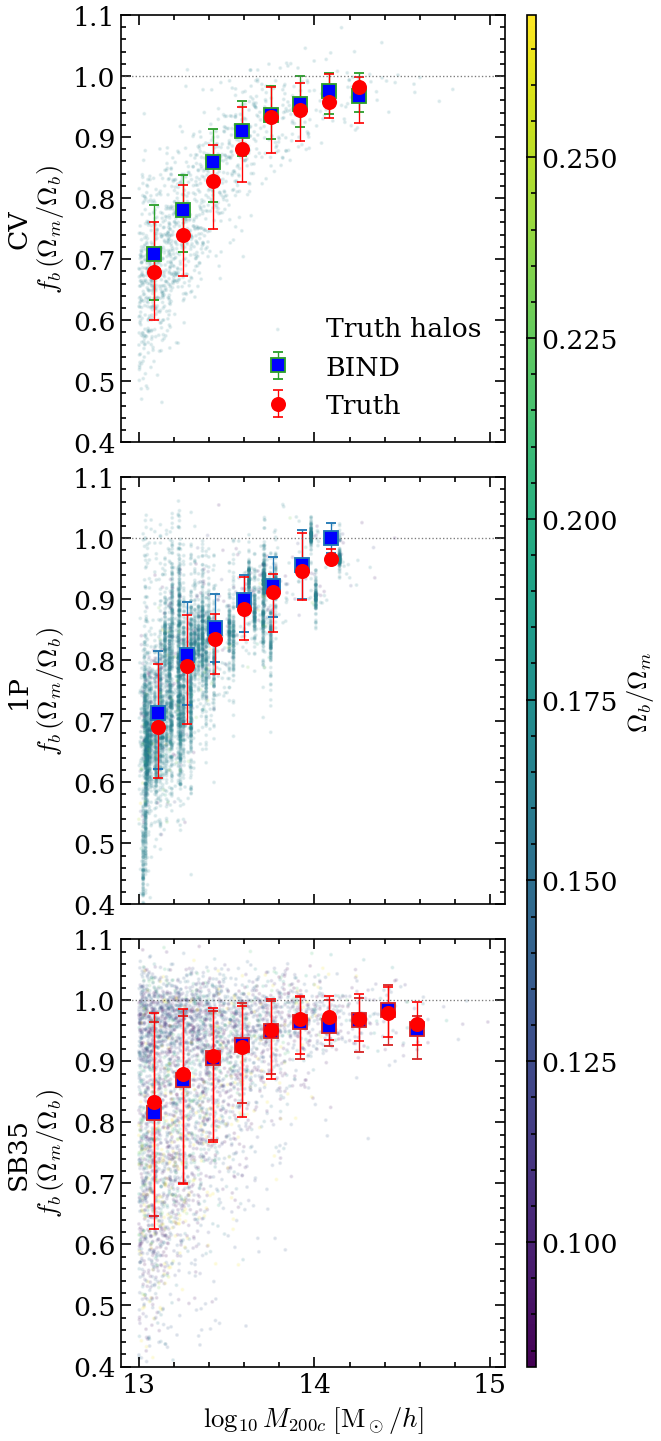

In [43]:
# ── Figure 1: normalised baryon fraction vs halo mass, by suite ─────────
import matplotlib.colors as mcolors


def _binned_stats(x, y, bins, min_count=15):
    """Median + 16th/84th percentile errorbars in x-bins; drop sparse bins."""
    if len(x) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    bm  = binned_statistic(x, y, statistic='median', bins=bins)
    blo = binned_statistic(x, y,
                           statistic=lambda v: np.percentile(v, 16), bins=bins)
    bhi = binned_statistic(x, y,
                           statistic=lambda v: np.percentile(v, 84), bins=bins)
    bn  = binned_statistic(x, y, statistic='count', bins=bins)
    xc  = 0.5 * (bm.bin_edges[:-1] + bm.bin_edges[1:])
    ok  = np.isfinite(bm.statistic) & (bn.statistic >= min_count)
    med    = bm.statistic[ok]
    err_lo = med - blo.statistic[ok]
    err_hi = bhi.statistic[ok] - med
    return xc[ok], med, err_lo, err_hi


def _f_b_cosmic(sub):
    """Per-halo Ω_b/Ω_m from the stored parameter columns."""
    omega_m = sub['p1'].to_numpy()
    omega_b = sub['p7'].to_numpy()
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(omega_m > 0, omega_b / omega_m, np.nan)


# Global colour normalisation across all suites
fb_cos_all = np.concatenate([
    _f_b_cosmic(obs_df[obs_df['suite'] == s]) for s in SUITES
])
fb_cos_all = fb_cos_all[np.isfinite(fb_cos_all)]
vmin, vmax = np.nanpercentile(fb_cos_all, [2, 98])
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = 0.12, 0.22
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = 'viridis'

K             = 'f_b_norm'
TRUTH_MARKER  = 'o'    # truth medians: circles
GEN_MARKER    = 's'    # gen medians:   squares

fig, axes = plt.subplots(3, 1, figsize=(5.5, 12),
                         sharex=True, constrained_layout=True)

for row, suite in enumerate(SUITES):
    ax      = axes[row]
    sub     = obs_df[obs_df['suite'] == suite]
    logm    = sub['logM'].to_numpy()
    t       = sub[f'truth_{K}'].to_numpy()
    g       = sub[f'gen_{K}'].to_numpy()
    f_b_cos = _f_b_cosmic(sub)

    mt = np.isfinite(logm) & np.isfinite(t) & np.isfinite(f_b_cos)
    mg = np.isfinite(logm) & np.isfinite(g) & np.isfinite(f_b_cos)

    # Halo cloud (truth, coloured by Ω_b/Ω_m)
    ax.scatter(logm[mt], t[mt], c=f_b_cos[mt], cmap=cmap, norm=norm,
               s=2, alpha=0.10,
               label='Truth halos' if row == 0 else None)

    if mt.sum() >= 30:
        x_lo = np.nanpercentile(logm[mt], 1)
        bins = np.linspace(x_lo, 15.0, 13)

        xt, tm, el_t, eh_t = _binned_stats(logm[mt], t[mt], bins)
        xg, gm, el_g, eh_g = _binned_stats(logm[mg], g[mg], bins)

        if len(xg):
            ax.errorbar(xg, gm, yerr=[el_g, eh_g],
                        fmt=GEN_MARKER, mfc='blue', mew=1.1, ms=8,
                        color=SUITE_COLORS[suite], linestyle='None',
                        capsize=3, elinewidth=0.8,
                        label='BIND' if row == 0 else None)
        if len(xt):
            ax.errorbar(xt, tm, yerr=[el_t, eh_t],
                        fmt=TRUTH_MARKER, color='red', ms=8, linestyle='None',
                        capsize=3, elinewidth=0.8,
                        label='Truth' if row == 0 else None)

    ax.axhline(1.0, color='0.35', lw=0.8, ls=':', alpha=0.8)
    ax.set_ylabel(SUITE_DISPLAY[suite] + '\n'
                  + r'$f_b\,(\Omega_m/\Omega_b)$')
    ax.set_ylim(0.4, 1.1)
    # ax.grid(axis='y', alpha=0.2)

axes[-1].set_xlabel(r'$\log_{10} M_{200c}\;[{\rm M}_\odot/h]$')
axes[0].legend(loc='best')

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=.1, pad=0.02,
                    aspect=150)
cbar.set_label(r'$\Omega_b/\Omega_m$')
# plt.tight_layout()

save_fig(fig, 'obs_baryon_fraction')
plt.show()


## CV halo masses & scaling-relation fits

Loads truth + BIND2 patches across the 28 CV simulations, computes per-halo
`M_dm`/`M_gas`/`M_star` within R200c, and fits the mean scaling relations.
Uses the `fm_two_head_no_pmm` checkpoint (constant `MODEL_CV` defined above)
to match the published analysis.


In [28]:
from scipy import stats

CV_ROOT = SUITE_ROOT / 'CV'
CV_SIMS = list(range(28))     # sim_0 through sim_27

# Per-halo aggregates accumulated across all CV sims
all_halo_mass, all_radii_pix = [], []
all_Mdm,   all_Mgas,   all_Mstar   = [], [], []
all_Mdm_g, all_Mgas_g, all_Mstar_g = [], [], []

print(f'Loading {len(CV_SIMS)} CV simulations (model = {MODEL_CV}) ...')

for sim_idx in CV_SIMS:
    sim_path = CV_ROOT / f'sim_{sim_idx}' / SNAP
    cat_path = sim_path / MASS_TAG / 'halo_catalog.npz'
    fm_path  = sim_path / 'full_maps.npz'
    gen_path = sim_path / MASS_TAG / MODEL_CV / 'generated_halos.npz'

    if not (cat_path.exists() and fm_path.exists() and gen_path.exists()):
        print(f'  sim_{sim_idx}: missing files, skipping')
        continue

    cat = np.load(cat_path)
    if 'radii' not in cat.files:
        print(f'  sim_{sim_idx}: unexpected catalog format (keys={cat.files}), skipping')
        continue

    fm     = np.load(fm_path)
    gen_np = np.load(gen_path)['generated']                     # (N, 3, 128, 128)
    truth  = fm['truth_maps']

    cen_pix = centers_to_pixels(cat['centers'])
    r_pix   = cat['radii'] / KPC_PER_PIX
    n       = len(cen_pix)

    Mdm   = np.empty(n);   Mgas   = np.empty(n);   Mstar   = np.empty(n)
    Mdm_g = np.empty(n);   Mgas_g = np.empty(n);   Mstar_g = np.empty(n)
    for i, (cx, cy) in enumerate(cen_pix):
        r = float(r_pix[i])
        Mdm[i]    = aperture_sum_raw(extract_patch(truth[0], int(cx), int(cy)), r)
        Mgas[i]   = aperture_sum_raw(extract_patch(truth[1], int(cx), int(cy)), r)
        Mstar[i]  = aperture_sum_raw(extract_patch(truth[2], int(cx), int(cy)), r)
        Mdm_g[i]   = aperture_sum_raw(gen_np[i, 0], r)
        Mgas_g[i]  = aperture_sum_raw(gen_np[i, 1], r)
        Mstar_g[i] = aperture_sum_raw(gen_np[i, 2], r)

    all_halo_mass.append(cat['masses'])
    all_radii_pix.append(r_pix)
    all_Mdm.append(Mdm);     all_Mgas.append(Mgas);     all_Mstar.append(Mstar)
    all_Mdm_g.append(Mdm_g); all_Mgas_g.append(Mgas_g); all_Mstar_g.append(Mstar_g)

    print(f'  sim_{sim_idx:02d}: {n:4d} halos  '
          f'R200c {r_pix.min():.1f}–{r_pix.max():.1f} px')

halo_mass = np.concatenate(all_halo_mass)
radii_pix = np.concatenate(all_radii_pix)
Mdm   = np.concatenate(all_Mdm);   Mgas   = np.concatenate(all_Mgas);   Mstar   = np.concatenate(all_Mstar)
Mdm_g = np.concatenate(all_Mdm_g); Mgas_g = np.concatenate(all_Mgas_g); Mstar_g = np.concatenate(all_Mstar_g)
Mbaryon   = Mgas   + Mstar
Mbaryon_g = Mgas_g + Mstar_g

print(f'\nPixel scale : {KPC_PER_PIX:.2f} kpc/h per px')
print(f'Total halos : {len(halo_mass)}  (across {len(CV_SIMS)} sims)')
print(f'R200c range : {radii_pix.min():.1f} – {radii_pix.max():.1f} px')


Loading 28 CV simulations (model = fm_two_head_no_pmm) ...
  sim_00:   45 halos  R200c 7.2–21.4 px
  sim_01:   51 halos  R200c 7.2–20.3 px
  sim_02:   49 halos  R200c 7.2–16.8 px
  sim_03:   37 halos  R200c 7.3–24.0 px
  sim_04:   46 halos  R200c 7.2–17.8 px
  sim_05:   45 halos  R200c 7.2–18.2 px
  sim_06:   31 halos  R200c 7.2–22.3 px
  sim_07:   34 halos  R200c 7.3–21.2 px
  sim_08:   51 halos  R200c 7.2–16.2 px
  sim_09:   47 halos  R200c 7.2–20.3 px
  sim_10:   35 halos  R200c 7.2–20.8 px
  sim_11:   47 halos  R200c 7.2–18.5 px
  sim_12:   36 halos  R200c 7.2–23.9 px
  sim_13:   40 halos  R200c 7.2–18.3 px
  sim_14:   50 halos  R200c 7.2–18.0 px
  sim_15:   44 halos  R200c 7.2–19.7 px
  sim_16:   47 halos  R200c 7.2–18.7 px
  sim_17: unexpected catalog format (keys=['centers', 'params', 'masses', 'halo_masses', 'halo_positions']), skipping
  sim_18:   50 halos  R200c 7.3–15.1 px
  sim_19:   46 halos  R200c 7.3–16.0 px
  sim_20:   46 halos  R200c 7.2–15.4 px
  sim_21:   40 halos  R

In [29]:
# ── fit log–log mean scaling relations and tabulate slope/scatter ────────
def fit_mean_relation(x, y, min_val=1.0):
    """OLS fit log10(y) = α·log10(x) + β. Returns (α, β, σ, mask, residual)."""
    mask = (x > min_val) & (y > min_val) & np.isfinite(x) & np.isfinite(y)
    lx, ly = np.log10(x[mask]), np.log10(y[mask])
    slope, intercept, *_ = stats.linregress(lx, ly)
    resid_m = ly - (slope * lx + intercept)
    resid_full = np.full(len(x), np.nan)
    resid_full[mask] = resid_m
    return slope, intercept, resid_m.std(), mask, resid_full


# (x_truth, y_truth, x_gen, y_gen, xlabel, ylabel)
RELATION_DEFS = {
    'Mgas–Mstar': (Mstar,     Mgas,     Mstar_g,   Mgas_g,
                   r'$M_\star$',         r'$M_\mathrm{gas}$'),
    'Mdm–Mstar':  (Mstar,     Mdm,      Mstar_g,   Mdm_g,
                   r'$M_\star$',         r'$M_\mathrm{dm}$'),
    'SHMR':       (halo_mass, Mstar,    halo_mass, Mstar_g,
                   r'$M_\mathrm{200c}$', r'$M_\star$'),
    'GasFrac':    (halo_mass, Mgas,     halo_mass, Mgas_g,
                   r'$M_\mathrm{200c}$', r'$M_\mathrm{gas}$'),
    'BaryonFrac': (halo_mass, Mbaryon,  halo_mass, Mbaryon_g,
                   r'$M_\mathrm{200c}$', r'$M_\mathrm{baryon}$'),
}

fits_t, fits_g = {}, {}
print(f"{'Relation':>14s}   {'truth α':>8s} {'truth σ':>8s}   "
      f"{'gen α':>8s} {'gen σ':>8s}")
for key, (xt, yt, xg, yg, xl, yl) in RELATION_DEFS.items():
    at, bt, st, mt, rt = fit_mean_relation(xt, yt)
    ag, bg, sg, mg, rg = fit_mean_relation(xg, yg)
    fits_t[key] = dict(alpha=at, beta=bt, scatter=st, mask=mt, resid=rt,
                       x=xt, y=yt, xlabel=xl, ylabel=yl)
    fits_g[key] = dict(alpha=ag, beta=bg, scatter=sg, mask=mg, resid=rg,
                       x=xg, y=yg, xlabel=xl, ylabel=yl)
    print(f'  {key:>14s}   {at:+.3f}   {st:.3f}     {ag:+.3f}   {sg:.3f}')


      Relation    truth α  truth σ      gen α    gen σ
      Mgas–Mstar   +1.167   0.114     +1.142   0.107
       Mdm–Mstar   +0.968   0.079     +0.969   0.075
            SHMR   +0.958   0.124     +0.958   0.124
         GasFrac   +1.195   0.129     +1.165   0.127
      BaryonFrac   +1.175   0.125     +1.146   0.124


## Figure 2 — Per-relation scaling fits

Each relation is modelled as a log–log power law fitted by ordinary least squares (OLS):

$$\log_{10} y_i = \alpha \log_{10} x_i + \beta + r_i$$

The OLS estimators minimise $\sum_i r_i^2$, giving slope $\hat\alpha$ and intercept $\hat\beta$.

**Per-halo residual** (used to colour the scatter points):

$$r_i = \log_{10} y_i - \bigl(\hat\alpha\,\log_{10} x_i + \hat\beta\bigr)$$

**Intrinsic scatter** (standard deviation of residuals, reported in each panel):

$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N} r_i^2}$$

The grey band shows $\hat\alpha\,\log_{10} x + \hat\beta \pm \sigma$.

**Relations plotted** (all masses in $\mathrm{M}_\odot\,h^{-1}$, measured within $R_{200c}$):

| Panel | $x$ | $y$ |
|-------|-----|-----|
| $M_{\rm gas}$–$M_\star$ | $M_\star$ | $M_{\rm gas}$ |
| $M_{\rm DM}$–$M_\star$  | $M_\star$ | $M_{\rm DM}$  |
| SHMR                    | $M_{200c}$ (DMO) | $M_\star$ |
| Baryon fraction         | $M_{200c}$ (DMO) | $M_{\rm gas}+M_\star$ |

Colour scale: $r_i$ clipped to $\pm 2\sigma_{\rm max}$ (shared across all panels and both rows).


  wrote paper_figures/scaling_fits.pdf
  wrote paper_figures/scaling_fits.png


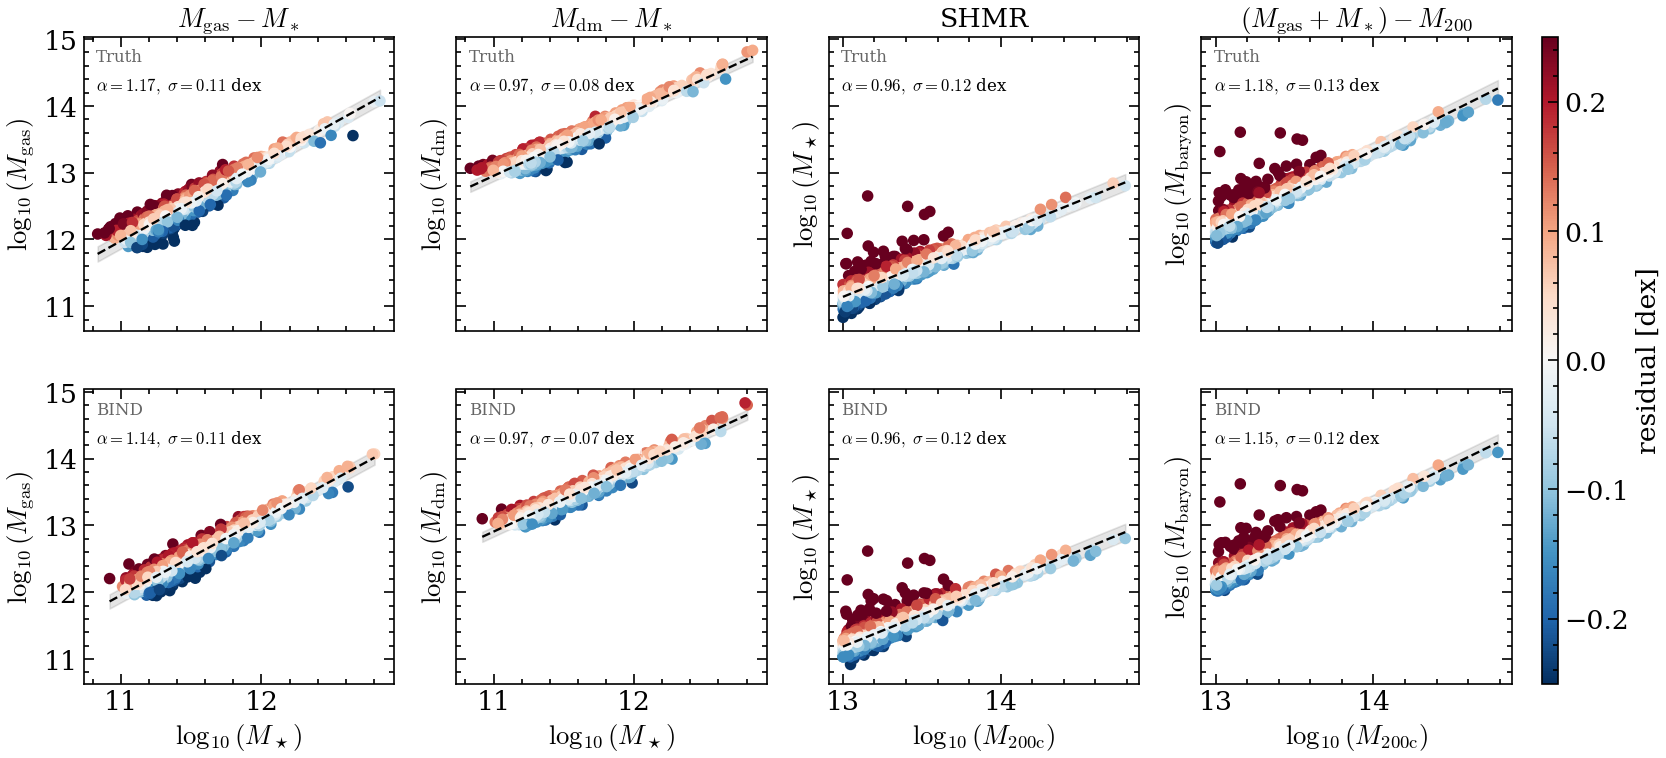

In [60]:
# ── Figure 2: per-relation scaling fits, residual-coloured ───────────────
# GasFrac dropped (degenerate with BaryonFrac)
REL_KEYS = [k for k in RELATION_DEFS if k != 'GasFrac']
n_rel = len(REL_KEYS)
titles = [r'$M_{\rm gas} - M_*$', r'$M_{\rm dm} - M_*$', r'SHMR', r'$(M_{\rm gas} + M_*) - M_{200}$']

# Global residual colour range: ±2σ across all relations & both rows
all_scatters = [fits_t[k]['scatter'] for k in REL_KEYS] + \
               [fits_g[k]['scatter'] for k in REL_KEYS]
global_clim = 2.0 * max(all_scatters)
RESID_NORM = mcolors.Normalize(vmin=-global_clim, vmax=global_clim)
RESID_CMAP = 'RdBu_r'

fig, axes = plt.subplots(2, n_rel, figsize=(16, 7),
                         sharex='col', sharey=True)

row_labels = ['Truth', 'BIND']
row_fits   = [fits_t, fits_g]

for row, (label, row_fd) in enumerate(zip(row_labels, row_fits)):
    for col, key in enumerate(REL_KEYS):
        ax = axes[row, col]
        fd = row_fd[key]
        m  = fd['mask']
        lx = np.log10(fd['x'][m])
        ly = np.log10(fd['y'][m])
        r  = fd['resid'][m]
        a, b, s = fd['alpha'], fd['beta'], fd['scatter']

        ax.scatter(lx, ly, c=r, cmap=RESID_CMAP, norm=RESID_NORM,
                   s=35, zorder=3)

        lx_line = np.linspace(lx.min(), lx.max(), 100)
        ax.plot(lx_line, a * lx_line + b, 'k--', lw=1.4, zorder=4)
        ax.fill_between(lx_line,
                        a * lx_line + b - s, a * lx_line + b + s,
                        color='k', alpha=0.10, zorder=2)

        if row == 0:
            ax.set_title(titles[col])
        if row == 1:
            ax.set_xlabel(r'$\log_{10}($' + fd['xlabel'] + r'$)$')
        ax.set_ylabel(r'$\log_{10}($' + fd['ylabel'] + r'$)$')
        if col > 0:
            ax.tick_params(axis='y', labelleft=False)

        ax.text(0.04, 0.96, label,
                transform=ax.transAxes, va='top',
                color='0.4', style='normal')
        ax.text(0.04, 0.87, fr'$\alpha={a:.2f},\ \sigma={s:.2f}$ dex',
                transform=ax.transAxes, va='top',
                bbox=dict(fc='white', ec='none', alpha=0.7))

# Single shared colorbar spanning both rows on the right
# axes.ravel().tolist() gives a flat list, required by fig.colorbar
sm = plt.cm.ScalarMappable(norm=RESID_NORM, cmap=RESID_CMAP)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, aspect=40)
cbar.set_label('residual [dex]')

# plt.tight_layout()

save_fig(fig, 'scaling_fits')
plt.show()

## Figure 3 — Cross-relation residual corner plot

Starting from the per-halo residual vectors from Figure 2, each halo $i$ carries a residual for every relation $k$:

$$\mathbf{r}_i = \bigl(r_{M_{\rm gas}-M_\star},\; r_{M_{\rm dm}-M_\star},\; r_{\rm SHMR},\; r_{(M_{\rm gas}+M_\star)-M_{200}}\bigr)_i$$

**Tail classification** (by the *column* relation $j$):

$$\text{high tail}: \quad r_{i,j} > +\sigma_j \qquad \text{low tail}: \quad r_{i,j} < -\sigma_j$$

where $\sigma_j$ is the scatter of relation $j$ (from Figure 2).

**2D KDE** for each classified subset $(x = r_{i,j},\; y = r_{i,k})$, using a Gaussian kernel with Scott's bandwidth rule:

$$h = n^{-1/(d+4)}\,\hat\sigma, \qquad d = 2$$

**Contour levels** enclose fractions $p \in \{68.27\%,\;95.45\%,\;99.73\%\}$ of the distribution (corresponding to $1\sigma / 2\sigma / 3\sigma$ of a 2D Gaussian):

$$\int_{\hat{f}(\mathbf{x}) \ge \lambda_p} \hat{f}(\mathbf{x})\,d\mathbf{x} = p$$

Solid contours = Truth; dotted contours = BIND. Red = over-dense tail ($r > +\sigma$); blue = under-dense tail ($r < -\sigma$). Diagonal panels show 1D histograms of the classified halos.


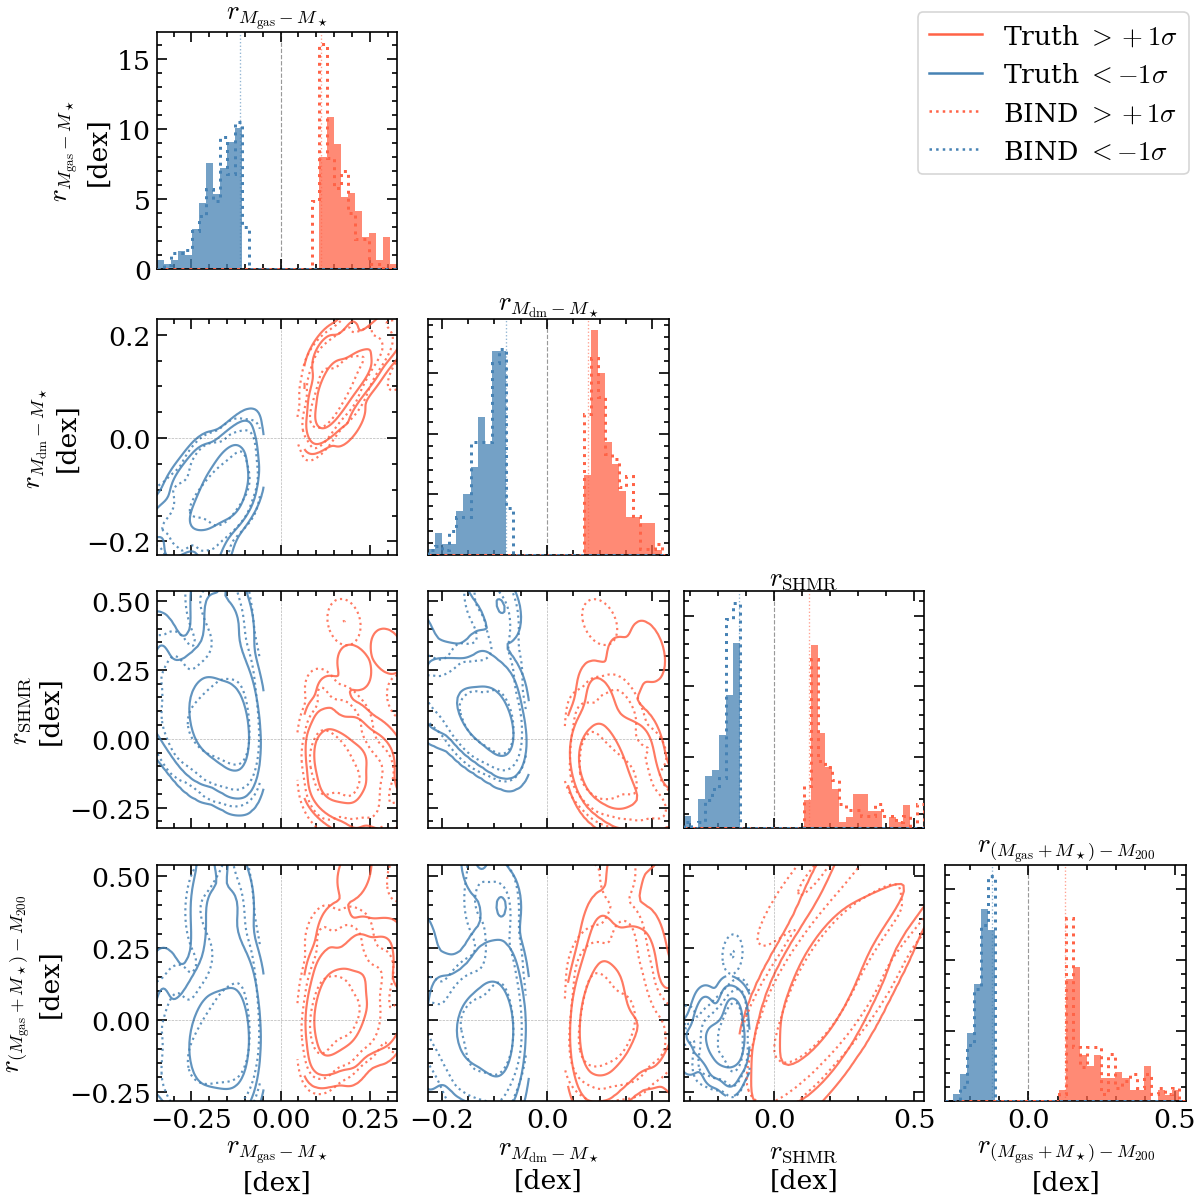

In [66]:
# ── Figure 3: cross-relation residual corner plot ────────────────────────
# Column j defines the ±1σ classification for that panel. Solid contours =
# Truth, dotted = Generated; levels enclose 1σ / 2σ / 3σ of each subset.
# `GasFrac` is dropped (degenerate with `BaryonFrac`).
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

all_keys = [k for k in RELATION_DEFS if k != 'GasFrac']
N_rel    = len(all_keys)

# halos valid in ALL retained relations for both truth & generated
both_mask = np.ones(len(halo_mass), dtype=bool)
for k in all_keys:
    both_mask &= fits_t[k]['mask'] & fits_g[k]['mask']

R_t   = np.stack([fits_t[k]['resid'][both_mask] for k in all_keys], axis=1)
R_g   = np.stack([fits_g[k]['resid'][both_mask] for k in all_keys], axis=1)
sig_t = np.array([fits_t[k]['scatter'] for k in all_keys])
sig_g = np.array([fits_g[k]['scatter'] for k in all_keys])

short_labels = {
    'Mgas–Mstar': r'$r_{M_{\rm gas}-M_\star}$',
    'Mdm–Mstar':  r'$r_{M_{\rm dm}-M_\star}$',
    'SHMR':       r'$r_{\rm SHMR}$',
    'BaryonFrac': r'$r_{(M_{\rm gas}+M_\star)-M_{200}}$',
}
slabels = [short_labels.get(k, k) for k in all_keys]

# Per-relation axis limits: 1–99th pct across truth+gen, with 15% padding
var_range = []
for k_idx in range(N_rel):
    vals = np.concatenate([R_t[:, k_idx], R_g[:, k_idx]])
    lo, hi = np.nanpercentile(vals, [1, 99])
    pad = 0.15 * (hi - lo)
    var_range.append((lo - pad, hi + pad))

_SIGMA_FRACS = [0.6827, 0.9545, 0.9973]   # 1σ / 2σ / 3σ enclosures in 2D


def _sigma_levels(z):
    """KDE density thresholds enclosing 1σ/2σ/3σ of the distribution."""
    z_sorted = np.sort(z.ravel())[::-1]
    cumfrac  = np.cumsum(z_sorted) / z_sorted.sum()
    levels   = []
    for frac in _SIGMA_FRACS:
        idx = np.searchsorted(cumfrac, frac)
        levels.append(float(z_sorted[min(idx, len(z_sorted) - 1)]))
    return sorted(set(levels))


def _kde_contour(ax, x, y, color, linestyle='-', lw=1.3, alpha=0.85):
    if len(x) < 10:
        return
    dx, dy = x.max() - x.min(), y.max() - y.min()
    if dx < 1e-10 or dy < 1e-10:
        return
    pad = 0.20
    kde = gaussian_kde(np.vstack([x, y]), bw_method='scott')
    xg, yg = np.mgrid[x.min() - pad * dx : x.max() + pad * dx : 100j,
                      y.min() - pad * dy : y.max() + pad * dy : 100j]
    z      = kde(np.vstack([xg.ravel(), yg.ravel()])).reshape(xg.shape)
    levels = _sigma_levels(z)
    if levels:
        ax.contour(xg, yg, z, levels=levels, colors=[color],
                   alpha=alpha, linewidths=lw, linestyles=linestyle)


fig, axes = plt.subplots(N_rel, N_rel, figsize=(10, 10),
                         constrained_layout=True)

for i in range(N_rel):
    for j in range(N_rel):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue

        # Tail classification by the column-j relation
        high_t = R_t[:, j] >  sig_t[j]
        low_t  = R_t[:, j] < -sig_t[j]
        high_g = R_g[:, j] >  sig_g[j]
        low_g  = R_g[:, j] < -sig_g[j]

        if i == j:
            lo, hi = var_range[i]
            bins = np.linspace(lo, hi, 35)
            ax.hist(R_t[high_t, i], bins=bins, color='tomato',    density=True,
                    alpha=0.75, zorder=2)
            ax.hist(R_t[low_t,  i], bins=bins, color='steelblue', density=True,
                    alpha=0.75, zorder=2)
            ax.hist(R_g[high_g, i], bins=bins, color='tomato',    density=True,
                    histtype='step', linestyle=':', lw=1.8, zorder=3)
            ax.hist(R_g[low_g,  i], bins=bins, color='steelblue', density=True,
                    histtype='step', linestyle=':', lw=1.8, zorder=3)
            ax.axvline( sig_t[i], c='tomato',    lw=0.8, ls=':', alpha=0.6)
            ax.axvline(-sig_t[i], c='steelblue', lw=0.8, ls=':', alpha=0.6)
            ax.axvline(0,         c='k',         lw=0.7, ls='--', alpha=0.4)
            ax.set_title(slabels[i], pad=2)
        else:
            _kde_contour(ax, R_t[high_t, j], R_t[high_t, i], 'tomato',    '-')
            _kde_contour(ax, R_t[low_t,  j], R_t[low_t,  i], 'steelblue', '-')
            _kde_contour(ax, R_g[high_g, j], R_g[high_g, i], 'tomato',    ':')
            _kde_contour(ax, R_g[low_g,  j], R_g[low_g,  i], 'steelblue', ':')
            ax.axhline(0, c='k', lw=0.4, ls='--', alpha=0.3)
            ax.axvline(0, c='k', lw=0.4, ls='--', alpha=0.3)

        ax.set_xlim(var_range[j])
        if i != j:
            ax.set_ylim(var_range[i])

        if j > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(slabels[i] + '\n[dex]')
        if i < N_rel - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(slabels[j] + '\n[dex]')

legend_elements = [
    Line2D([0], [0], color='tomato',    lw=1.5, ls='-',  label=r'Truth $>+1\sigma$'),
    Line2D([0], [0], color='steelblue', lw=1.5, ls='-',  label=r'Truth $<-1\sigma$'),
    Line2D([0], [0], color='tomato',    lw=1.5, ls=':',  label=r'BIND $>+1\sigma$'),
    Line2D([0], [0], color='steelblue', lw=1.5, ls=':',  label=r'BIND $<-1\sigma$'),
]
fig.legend(handles=legend_elements, loc='upper right', frameon=True)
plt.savefig(FIG_DIR / 'residual_corner_plot.pdf')
plt.show()
